# Rationalising Priors

- Implementing my big algorithm for choosing priors and then fitting models with different values of k and combinations of the prior frequencies.
- Then implement the model comparison with Occam penalty. 
- Use validation for model selection and test set for testing.

In [2]:
import pandas as pd
from astropy.time import Time
import matplotlib.pyplot as plt
import celerite2
import numpy as np
from celerite2 import terms
from scipy.optimize import minimize
from prettytable import PrettyTable


# Importing data
data = pd.read_csv(r"./Data/sind_all.txt", sep='\s', header = 1)
data.columns = ["JD", "sind"]
data['JD'] = data['JD'] + 2400000.0 # this file drops the 24 prefix
time_obj = Time(data["JD"].to_numpy(), format='jd', scale='tdb')
data["year"] = time_obj.jyear
data['datetime'] = time_obj.to_datetime(timezone=None)
data = data.set_index('datetime')

# No need to down sample the dataset here. yay!
def split_df(df, train_split=0.22, valid_split=0.59):
    n = len(df)
    train_idx = round(train_split * n)
    valid_idx = round((train_split + valid_split) * n)
    return df.iloc[:train_idx].copy(), df.iloc[train_idx:valid_idx].copy(), df.iloc[valid_idx:].copy()

# Split the data
train_df, valid_df, test_df = split_df(data)

C:\Users\Joey\AppData\Local\Temp\ipykernel_60856\583619345.py:12: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(r"./Data/sind_all.txt", sep='\s', header = 1)


- Plot Lomb-Scargle and add FAPs

In [3]:
def FAP(N, M, P):
    '''
    N is the number of datapoints in the time series from which the LS periodogram is derived.
    M is the number of independent frequencies M approx T x (fmax-fmin), where T is the number of years of data you have
    P is the power for which the FAP is desired.
    '''
    return  1 - ((1 - (1 - (2*P / (N-1)))** ((N-3)/2)) ** M)

def invFAP(N, M, FAP):
    '''
    Returns the power threshold corresponding to a given FAP level.
    Inverse of FAP function above.
    '''
    single_trial = 1 - (1 - FAP) ** (1/M)
    P = (N-1)/2 * (1 - single_trial ** (2/(N-3)))
    
    return P


0.6746139079242098
1397 46.653040862424064
[0.02411917 0.02568733 0.02857421]


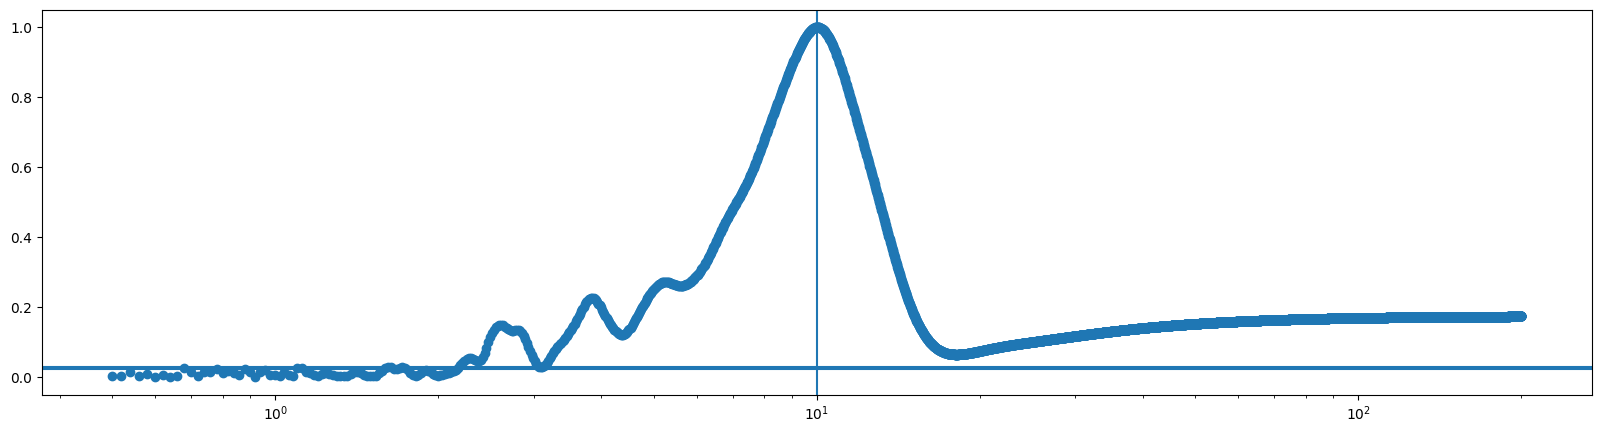

The best period is 10.017101710171017 years


In [11]:
# Lomb scargle 
# Lomb-Scargle finds periodic signals in unevnly sampled time series.
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks

# Define freq range
min_period = 0.5
max_period = 200
n_periods = 10000
periods = np.linspace(min_period, max_period, n_periods)
freq = 1 / periods

ls = LombScargle(train_df['year'], train_df['sind'])
power = ls.power(freq)

# # Normalise the powers to frac of max to aid in peak finding
max_power = max(power)
power /= max_power

noise = np.percentile(power, 75)
print(max_power)

# Find the Lomb-Scargle peak
peaks, properties = find_peaks(power, height = 0., prominence= 5 * noise) # peaks is an array of the indices of the input arrays with the peaks
peak_periods = periods[peaks]

# Things for calculating the FAP
N = len(train_df)
T = train_df['year'].max() - train_df['year'].min()
M = T * (1/min_period - 1/max_period)
print(N,M)

# FAPs of note
FAPs = np.array([10, 5, 1]) / 100
power_invFAPs = ls.false_alarm_level(FAPs, method = 'bootstrap') / max_power
# power_invFAPs = invFAP(N = N, M = M, FAP = FAPs)
# power_invFAPs = 2 * power_invFAPs / (N - 1)  # convert HB units to standard
# power_invFAPs /= max_power
print(power_invFAPs)

# plot the thing
fig, ax = plt.subplots(1, figsize = (20,5))
ax.set_xscale('log')
# ax.set_yscale('log')
ax.scatter(periods,power)
for peak_period in peak_periods:
    ax.axvline(peak_period)
for power_invFAP in power_invFAPs:
    ax.axhline(power_invFAP)
plt.show()

# print the best period
best_period = periods[np.argmax(power)]
print(f"The best period is {best_period} years")


- Generate fake data to test the LS thing
    - Generate between 1 and 3 sine waves
    - Randomly sample values based on the sum
    - Perform analysis to verify

In [5]:
import random

def generate_toy_signal(k = 3, time_range=30, seasonal=1, plot = False, mult = 10):
    '''
    Generates a fake signal so we can see if the periodogram is useful for identifying the priors.
    There are three possible ranges of the data. Short; medium; long.
    Short on order of days: 1/10 years
    Mid on order of decade: 10-20 ish years
    Long (Gleissman) on order of century: 100-200 years

    Chooses k out of 3 of them

    Time range is the number of years across which observations were taken
    Seasonal simulates observation gaps annually; seasonal = 1 takes all observations

    returns
    t in years
    '''
    bounds = {
        "short": ((10/365, 1), (0.05, 0.2)),
        "mid": ((7, 20),(0.5,10)),
        "long": ((100, 200),(0.1, 0.4))
    }

    # Choose the bounds
    chosen_bounds = dict(random.sample(list(bounds.items()), k=k))

    shortest_period = min(lo for (lo, hi), (blo, bhi) in chosen_bounds.values()) 
    dt = shortest_period * mult  # nyquist safe 

    # Chosen keys
    keys = chosen_bounds.keys()

    # Choose the periods
    periods = [np.random.uniform(lo,hi) for (lo, hi), (blo,bhi) in chosen_bounds.values()]

    # Choose the concomitant amplitudes
    amps = [np.random.uniform(blo, bhi) for (lo, hi), (blo, bhi) in chosen_bounds.values()]

    n_points = int(time_range / dt)
    t = np.sort(np.random.uniform(0, time_range, size=n_points))
    
    if seasonal < 1:
        t = t[np.mod(t, 1.0) < 0.6]

    # Find the y given by the chosen items
    components = {
        key: amp * np.sin(2 * np.pi * t / period + np.random.uniform(0, 2 * np.pi)) + np.random.normal(0,2, size = len(t))
        for key, period, amp in zip(keys, periods, amps)
    }

    if "long" in components and "mid" in components:
        y = (1 + components["long"]) * components["mid"]
        if "short" in components:
            y += components['short']
    else:
        y = sum(components.values())
    
    if plot:
        fig, ax = plt.subplots(figsize=(20,5))
        ax.scatter(t,y, marker = 'x', label = f"dt = {dt}")
        ax.legend()
    return t, y, dict(zip(keys, zip(periods, amps)))


- Now we can use this data to be able to write a function that uses the periodogram and model comparison to figure out how many peaks there are to use as priors.
- Since FAPs are not working, if there are more than 3 peaks we can select them by the strongest powers.
- Let us functionise the Lomb-Scargle periodogram code.

In [6]:
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks

def identify_peaks(t=None, y=None, df=None, plot=True, min_period=0.01, max_period=200, n_periods=10000, normalise=True, max_peaks=3):
    '''
    Identifies the peaks available to be used as priors in a GPR fitting.
    Takes in the DF, calculates the LSP, identifies the peaks and the number thereof.
    It uses simple heuristics to classify them into long, mid, and short ranges.

    Params
    plot: plots LSP if True
    min_period, max_period in years
    n_periods to set the resolution

    Returns
    The peak periods and their concomitant ranges.
    '''
    periods = np.linspace(min_period, max_period, n_periods)
    freq = 1 / periods

    if df is not None:
        ls = LombScargle(df['year'], df['sind'])
    elif t is not None and y is not None:
        ls = LombScargle(t, y)
    else:
        raise ValueError("Please define either the df, or t and y")

    powers = ls.power(freq)

    if normalise:
        max_power = max(powers)
        powers /= max_power

    noise = np.percentile(powers, 50)

    peak_idxs, _ = find_peaks(powers, height=0., prominence=noise)
    peak_periods = periods[peak_idxs]
    peak_powers = powers[peak_idxs]

    # Keep only the strongest max_peaks peaks
    if len(peak_periods) > max_peaks:
        top_idx = np.argsort(peak_powers)[-max_peaks:]
        peak_periods = peak_periods[top_idx]
        peak_powers = peak_powers[top_idx]

    # In each range, take the peak with highest power
    peak_info = {}
    peak_data = list(zip(peak_periods, peak_powers))

    peaks_s = [(p, pw) for p, pw in peak_data if p <= 1]
    peaks_m = [(p, pw) for p, pw in peak_data if 1 < p <= 50]
    peaks_l = [(p, pw) for p, pw in peak_data if p > 50]

    if peaks_s:
        peak_info['short'] = max(peaks_s, key=lambda x: x[1])[0]
    if peaks_m:
        peak_info['mid'] = max(peaks_m, key=lambda x: x[1])[0]
    if peaks_l:
        peak_info['long'] = max(peaks_l, key=lambda x: x[1])[0]

    if plot:
        colors = {'short': 'red', 'mid': 'green', 'long': 'orange'}
        fig, ax = plt.subplots(1, figsize=(20, 5))
        ax.scatter(periods, powers, marker='x', color='blue', label="Periodogram")
        for cycle_type, peak_period in peak_info.items():
            ax.axvline(peak_period, color=colors[cycle_type], label=f"Cycle type: {cycle_type}")
        ax.axhline(noise, label="Noise level", color='purple')
        ax.legend()
        plt.show()

    return peak_info


- Now test this by running the generation and the identification consecutively repeatedly. Compare the peaks and alleged cycle ranges

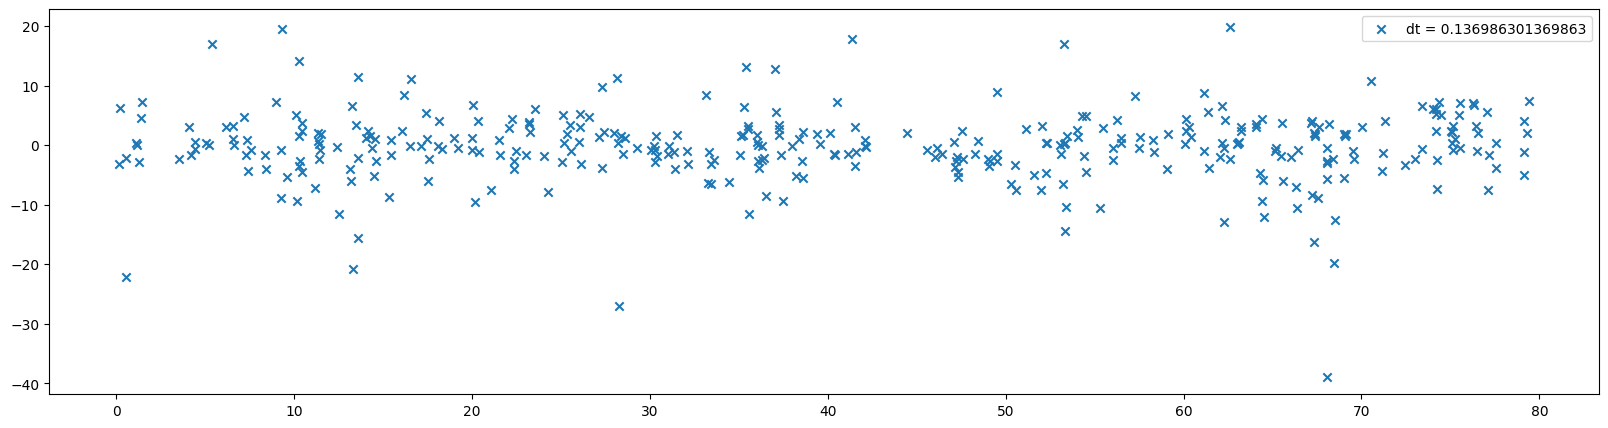

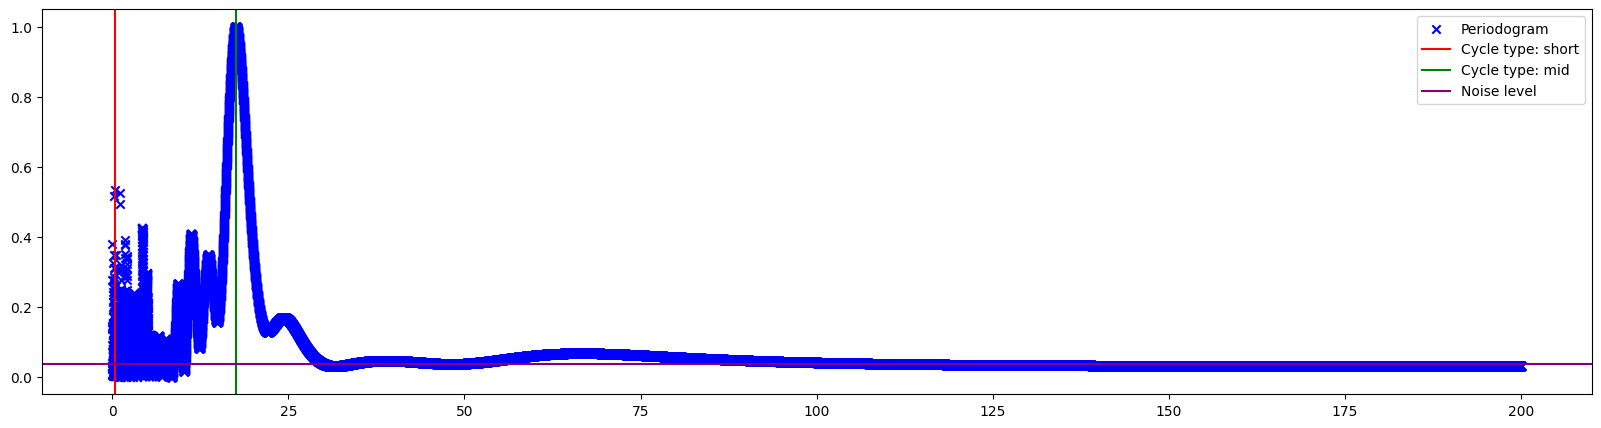

signal_data
{'short': (0.878872530495039, 0.15528191747966133), 'mid': (18.24041168154042, 1.6611449820378552), 'long': (120.2023730006259, 0.3643938592541328)}
peak_info
{'short': np.float64(0.3859887197743955), 'mid': np.float64(17.58147282945659)}


In [20]:
t, y, signal_data = generate_toy_signal(plot= True, time_range= 80, mult = 5, seasonal= 0.5)
peak_info = identify_peaks(t, y, plot = True, n_periods=50000)
print('signal_data')
print(signal_data)
print('peak_info')
print(peak_info)

- It appears to me that it is very hard to detect the short and long.
- Able to detect mid quite reliably.
- I wager that the difficulty for the short cycle is the Nyquist limit.
    - Ok this was wrong even for very small dt still could not detect. This must be an amplitude issue. Used 0.002 dt when short was 0.059.
    - IDIOT: THE REASON IT DID NOT DETECT WAS BECAUSE THE MIN PERIOD YOU WERE LOOKING FOR WAS HIGHER THAN THE MAXPERIOD OF SHORT CYC.
- The performance is still night gut genug.
- Ah ok increasing the n_periods improve short detection significantly. This is just priors so actually not too bad that it's a bit off. 

- Having now read the SM2016 paper it turn out that the FAP could be messy because the very strong solar cycle does not look like white noise. For the rest of the data, white noise is considerable vs the signal.

- The SM2016 paper also perform the peak analysis in two steps. 
    - First identify the main peak. Subtract that signal.
    - Perform the same analysis on the residual signal. 
        -  A strong signal (the dominant cycle) bleeds power into nearby frequencies in the periodogram — this is spectral leakage from the finite, gapped time series. This elevated "skirt" around the dominant peak raises the local noise floor, burying weaker nearby signals below the FAP threshold. Fit and subtract the dominant signal, and that skirt disappears.
        - After subtracting a well-fitted dominant signal, the residual variance drops. The FAP threshold is set relative to the noise floor, so a lower noise floor means weaker signals become statistically significant — signals that were below your 5 * noise prominence cut in the raw periodogram now clear it.
    - **TEST THE FAP OF THE RESIDUAL IT SHOULD BE MORE REASONABLE**
---
- Now I will:
    - Rewrite the short and long amplitudes to be relative to the mid amplitude.
        - Change the short period to be a function of the SM2016 thing. This only works for FGK stars.
        - Our sun is a G-type star so this works well for our validation.
    - Define 2 linspaces of short/mid and long/mid ratio.
    - Draw the frequencies n_draws = 1 number of times for each. Use very small dt so very small mult. Choose say 100 years of data which is more than optimistic.
    - Find the correct to within toleranc = 10%. 
    - Find the probability at various amplitudes that the long and short can be found this way.
    - Use this to justify that we can just use SM2016 on the mid to estimate the short and 100 ish to estimate the long prior.
    - Compare these values with the LS power of out sun at these frequencies.

- *Probably have to run this on CSD3 after and save the plots/data then import the plots back into here* 


In [8]:
# Rewrite the short and long amplitudes to be relative to the mid amplitude
# Rewrite the short period to be a function of SM2016 !!!! ONLY FOR FGK STARS DOES NOT WORK FOR M stype

import random

def generate_toy_signal(k = 3, time_range=30, seasonal=1, plot = False, mult = 10):
    '''
    Generates a fake signal so we can see if the periodogram is useful for identifying the priors.
    There are three possible ranges of the data. Short; medium; long.
    Short on order of days: 1/10 years
    Mid on order of decade: 10-20 ish years
    Long (Gleissman) on order of century: 100-200 years

    Chooses k out of 3 of them

    Time range is the number of years across which observations were taken
    Seasonal simulates observation gaps annually; seasonal = 1 takes all observations

    returns
    t in years
    '''
    bounds = {
        "short": ((10/365, 1), (0.05, 0.2)),
        "mid": ((7, 20),(0.5,10)),
        "long": ((100, 200),(0.1, 0.4))
    }

    # Choose the bounds
    chosen_bounds = dict(random.sample(list(bounds.items()), k=k))

    shortest_period = min(lo for (lo, hi), (blo, bhi) in chosen_bounds.values()) 
    dt = shortest_period * mult  # nyquist safe 

    # Chosen keys
    keys = chosen_bounds.keys()

    # Choose the periods
    periods = [np.random.uniform(lo,hi) for (lo, hi), (blo,bhi) in chosen_bounds.values()]

    # Choose the concomitant amplitudes
    amps = [np.random.uniform(blo, bhi) for (lo, hi), (blo, bhi) in chosen_bounds.values()]

    n_points = int(time_range / dt)
    t = np.sort(np.random.uniform(0, time_range, size=n_points))
    
    if seasonal < 1:
        t = t[np.mod(t, 1.0) < 0.6]

    # Find the y given by the chosen items
    components = {
        key: amp * np.sin(2 * np.pi * t / period + np.random.uniform(0, 2 * np.pi)) + np.random.normal(0,2, size = len(t))
        for key, period, amp in zip(keys, periods, amps)
    }

    if "long" in components and "mid" in components:
        y = (1 + components["long"]) * components["mid"]
        if "short" in components:
            y += components['short']
    else:
        y = sum(components.values())
    
    if plot:
        fig, ax = plt.subplots(figsize=(20,5))
        ax.scatter(t,y, marker = 'x', label = f"dt = {dt}")
        ax.legend()
    return t, y, dict(zip(keys, zip(periods, amps)))


- Comment yada yada yada

---
- Now take the marginal in dt to show that very high cadence is required to see the short cycle here.
- Further justifies just taking SM2016 relation on the mid as our key form of estimation.

- Comment yada yada yada

---
- Function to return the priors